<a href="https://www.kaggle.com/code/sonawanelalitsunil/binary-classification-with-a-bank-ml-97?scriptVersionId=257957561" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/playground-series-s5e8/sample_submission.csv
/kaggle/input/playground-series-s5e8/train.csv
/kaggle/input/playground-series-s5e8/test.csv


## Title:
🔍 Binary Classification with a Bank Dataset

## Description:
This project focuses on building a binary classification model using a bank dataset to predict customer behavior, such as whether a client will subscribe to a term deposit. The dataset includes features like demographic details, account information, and marketing interactions. The process involves data preprocessing (handling missing values, encoding categorical variables, scaling), splitting the data into training and testing sets, and applying various machine learning algorithms such as Logistic Regression, Decision Tree, Random Forest, SVM, KNN, and Naive Bayes. Model performance is evaluated using accuracy, confusion matrix, and other metrics to identify the most effective approach for predicting customer outcomes.

## Import dataset

In [2]:
train =pd.read_csv('/kaggle/input/playground-series-s5e8/train.csv')
test =pd.read_csv('/kaggle/input/playground-series-s5e8/test.csv')
sample =pd.read_csv('/kaggle/input/playground-series-s5e8/sample_submission.csv')

In [3]:
train.head()

,id,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,0,42,technician,married,secondary,no,7,no,no,cellular,25,aug,117,3,-1,0,unknown,0
1,1,38,blue-collar,married,secondary,no,514,no,no,unknown,18,jun,185,1,-1,0,unknown,0
2,2,36,blue-collar,married,secondary,no,602,yes,no,unknown,14,may,111,2,-1,0,unknown,0
3,3,27,student,single,secondary,no,34,yes,no,unknown,28,may,10,2,-1,0,unknown,0
4,4,26,technician,married,secondary,no,889,yes,no,cellular,3,feb,902,1,-1,0,unknown,1


In [4]:
test.head()

,id,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome
0,750000,32,blue-collar,married,secondary,no,1397,yes,no,unknown,21,may,224,1,-1,0,unknown
1,750001,44,management,married,tertiary,no,23,yes,no,cellular,3,apr,586,2,-1,0,unknown
2,750002,36,self-employed,married,primary,no,46,yes,yes,cellular,13,may,111,2,-1,0,unknown
3,750003,58,blue-collar,married,secondary,no,-1380,yes,yes,unknown,29,may,125,1,-1,0,unknown
4,750004,28,technician,single,secondary,no,1950,yes,no,cellular,22,jul,181,1,-1,0,unknown


In [5]:
train.tail()

,id,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
749995,749995,29,services,single,secondary,no,1282,no,yes,unknown,4,jul,1006,2,-1,0,unknown,1
749996,749996,69,retired,divorced,tertiary,no,631,no,no,cellular,19,aug,87,1,-1,0,unknown,0
749997,749997,50,blue-collar,married,secondary,no,217,yes,no,cellular,17,apr,113,1,-1,0,unknown,0
749998,749998,32,technician,married,secondary,no,-274,no,no,cellular,26,aug,108,6,-1,0,unknown,0
749999,749999,42,technician,married,secondary,no,1559,no,no,cellular,4,aug,143,1,1,7,failure,0


In [6]:
test.tail()

,id,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome
249995,999995,43,management,married,tertiary,no,0,yes,no,cellular,18,nov,65,2,-1,0,unknown
249996,999996,40,services,married,unknown,no,522,yes,no,cellular,19,nov,531,1,189,1,failure
249997,999997,63,retired,married,primary,no,33,no,no,cellular,3,jul,178,1,92,8,success
249998,999998,50,blue-collar,married,primary,no,2629,yes,no,unknown,30,may,163,2,-1,0,unknown
249999,999999,29,student,single,tertiary,no,722,no,no,cellular,6,apr,119,1,-1,0,unknown


In [7]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 750000 entries, 0 to 749999
Data columns (total 18 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   id         750000 non-null  int64 
 1   age        750000 non-null  int64 
 2   job        750000 non-null  object
 3   marital    750000 non-null  object
 4   education  750000 non-null  object
 5   default    750000 non-null  object
 6   balance    750000 non-null  int64 
 7   housing    750000 non-null  object
 8   loan       750000 non-null  object
 9   contact    750000 non-null  object
 10  day        750000 non-null  int64 
 11  month      750000 non-null  object
 12  duration   750000 non-null  int64 
 13  campaign   750000 non-null  int64 
 14  pdays      750000 non-null  int64 
 15  previous   750000 non-null  int64 
 16  poutcome   750000 non-null  object
 17  y          750000 non-null  int64 
dtypes: int64(9), object(9)
memory usage: 103.0+ MB


In [8]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 17 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   id         250000 non-null  int64 
 1   age        250000 non-null  int64 
 2   job        250000 non-null  object
 3   marital    250000 non-null  object
 4   education  250000 non-null  object
 5   default    250000 non-null  object
 6   balance    250000 non-null  int64 
 7   housing    250000 non-null  object
 8   loan       250000 non-null  object
 9   contact    250000 non-null  object
 10  day        250000 non-null  int64 
 11  month      250000 non-null  object
 12  duration   250000 non-null  int64 
 13  campaign   250000 non-null  int64 
 14  pdays      250000 non-null  int64 
 15  previous   250000 non-null  int64 
 16  poutcome   250000 non-null  object
dtypes: int64(8), object(9)
memory usage: 32.4+ MB


In [9]:
train.describe()

,id,age,balance,day,duration,campaign,pdays,previous,y
count,750000.000000,750000.000000,750000.000000,750000.000000,750000.000000,750000.000000,750000.000000,750000.000000,750000.000000
mean,374999.500000,40.926395,1204.067397,16.117209,256.229144,2.577008,22.412733,0.298545,0.120651
std,216506.495284,10.098829,2836.096759,8.250832,272.555662,2.718514,77.319998,1.335926,0.325721
min,0.000000,18.000000,-8019.000000,1.000000,1.000000,1.000000,-1.000000,0.000000,0.000000
25%,187499.750000,33.000000,0.000000,9.000000,91.000000,1.000000,-1.000000,0.000000,0.000000
50%,374999.500000,39.000000,634.000000,17.000000,133.000000,2.000000,-1.000000,0.000000,0.000000
75%,562499.250000,48.000000,1390.000000,21.000000,361.000000,3.000000,-1.000000,0.000000,0.000000
max,749999.000000,95.000000,99717.000000,31.000000,4918.000000,63.000000,871.000000,200.000000,1.000000


In [10]:
test.describe()

,id,age,balance,day,duration,campaign,pdays,previous
count,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000
mean,874999.500000,40.932332,1197.426352,16.116068,255.342260,2.573548,22.280028,0.303728
std,72168.927986,10.081613,2741.520699,8.258509,271.404326,2.709661,76.915879,1.384574
min,750000.000000,18.000000,-8019.000000,1.000000,3.000000,1.000000,-1.000000,0.000000
25%,812499.750000,33.000000,0.000000,9.000000,91.000000,1.000000,-1.000000,0.000000
50%,874999.500000,39.000000,631.000000,17.000000,133.000000,2.000000,-1.000000,0.000000
75%,937499.250000,48.000000,1389.000000,21.000000,353.000000,3.000000,-1.000000,0.000000
max,999999.000000,95.000000,98517.000000,31.000000,4918.000000,58.000000,871.000000,150.000000


In [11]:
train.isnull().sum()

id           0
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

In [12]:
test.isnull().sum()

id           0
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
dtype: int64

In [13]:
train.duplicated().sum()

0

In [14]:
test.duplicated().sum()

0

In [15]:
train.dtypes

id            int64
age           int64
job          object
marital      object
education    object
default      object
balance       int64
housing      object
loan         object
contact      object
day           int64
month        object
duration      int64
campaign      int64
pdays         int64
previous      int64
poutcome     object
y             int64
dtype: object

In [16]:
test.dtypes

id            int64
age           int64
job          object
marital      object
education    object
default      object
balance       int64
housing      object
loan         object
contact      object
day           int64
month        object
duration      int64
campaign      int64
pdays         int64
previous      int64
poutcome     object
dtype: object

In [17]:
train.shape

(750000, 18)

In [18]:
test.shape

(250000, 17)

In [19]:
train.columns

Index(['id', 'age', 'job', 'marital', 'education', 'default', 'balance',
       'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign',
       'pdays', 'previous', 'poutcome', 'y'],
      dtype='object')

In [20]:
test.columns

Index(['id', 'age', 'job', 'marital', 'education', 'default', 'balance',
       'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign',
       'pdays', 'previous', 'poutcome'],
      dtype='object')

In [21]:
data_null = round(train.isna().sum() / train.shape[0] * 100, 2)
data_null.to_frame(name = 'percent NULL train data (%)')

,percent NULL train data (%)
id,0.0
age,0.0
job,0.0
marital,0.0
education,0.0
default,0.0
balance,0.0
housing,0.0
loan,0.0
contact,0.0


In [22]:
train.head()

,id,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,0,42,technician,married,secondary,no,7,no,no,cellular,25,aug,117,3,-1,0,unknown,0
1,1,38,blue-collar,married,secondary,no,514,no,no,unknown,18,jun,185,1,-1,0,unknown,0
2,2,36,blue-collar,married,secondary,no,602,yes,no,unknown,14,may,111,2,-1,0,unknown,0
3,3,27,student,single,secondary,no,34,yes,no,unknown,28,may,10,2,-1,0,unknown,0
4,4,26,technician,married,secondary,no,889,yes,no,cellular,3,feb,902,1,-1,0,unknown,1


In [23]:
test.head()

,id,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome
0,750000,32,blue-collar,married,secondary,no,1397,yes,no,unknown,21,may,224,1,-1,0,unknown
1,750001,44,management,married,tertiary,no,23,yes,no,cellular,3,apr,586,2,-1,0,unknown
2,750002,36,self-employed,married,primary,no,46,yes,yes,cellular,13,may,111,2,-1,0,unknown
3,750003,58,blue-collar,married,secondary,no,-1380,yes,yes,unknown,29,may,125,1,-1,0,unknown
4,750004,28,technician,single,secondary,no,1950,yes,no,cellular,22,jul,181,1,-1,0,unknown


## Data visualizations

## Train data

<Figure size 1200x600 with 0 Axes>

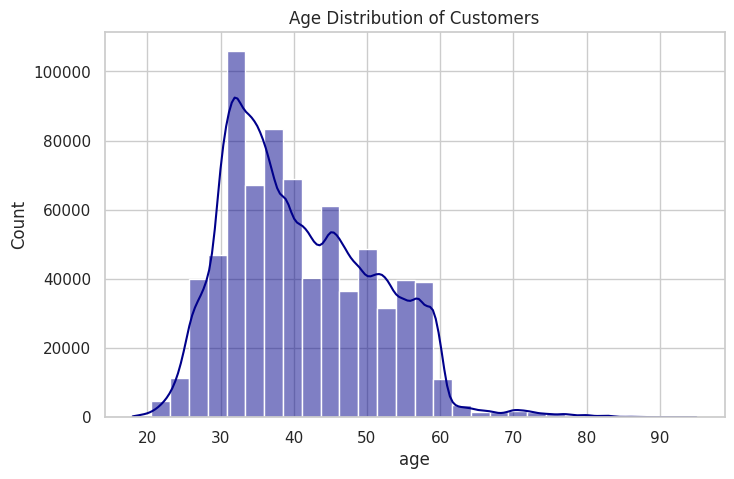

In [24]:
# Set style
sns.set(style="whitegrid", palette="muted")
plt.figure(figsize=(12,6))

# 1. Distribution of Age
plt.figure(figsize=(8,5))
sns.histplot(train['age'], bins=30, kde=True, color="darkblue")
plt.title("Age Distribution of Customers")
plt.show()

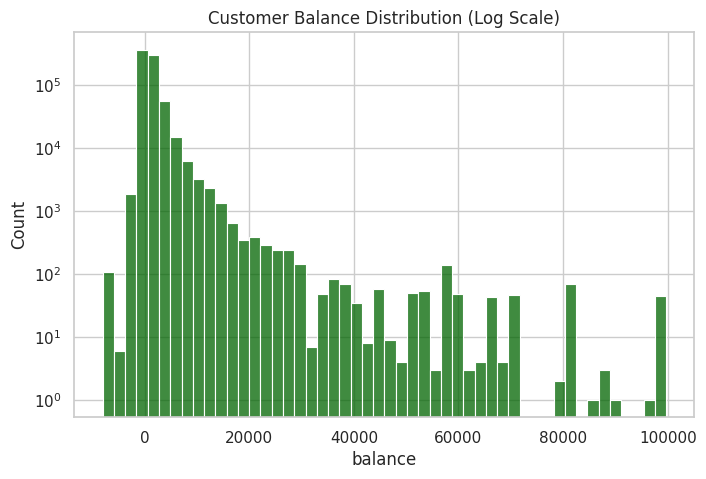

In [25]:
plt.figure(figsize=(8,5))
sns.histplot(train['balance'], bins=50, color="darkgreen")
plt.yscale("log")
plt.title("Customer Balance Distribution (Log Scale)")
plt.show()

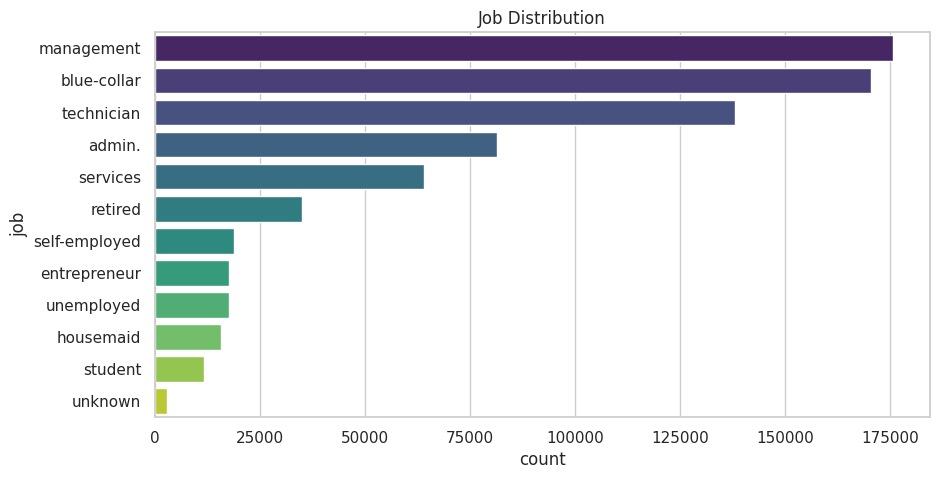

In [26]:
plt.figure(figsize=(10,5))
sns.countplot(y=train['job'], order=train['job'].value_counts().index, palette="viridis")
plt.title("Job Distribution")
plt.show()

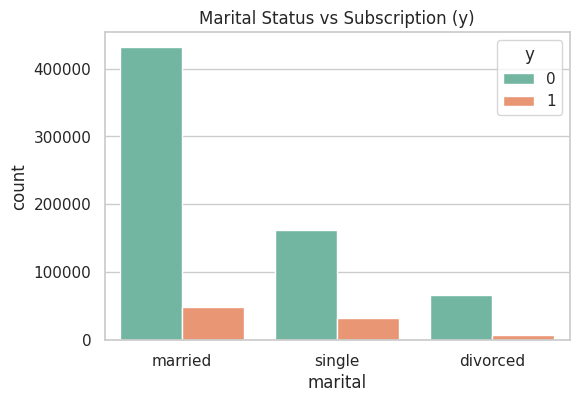

In [27]:
plt.figure(figsize=(6,4))
sns.countplot(x='marital', hue='y', data=train, palette="Set2")
plt.title("Marital Status vs Subscription (y)")
plt.show()

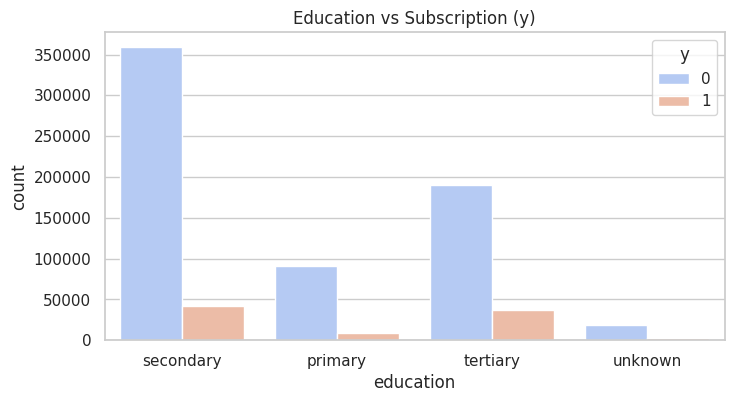

In [28]:
plt.figure(figsize=(8,4))
sns.countplot(x='education', hue='y', data=train, palette="coolwarm")
plt.title("Education vs Subscription (y)")
plt.show()

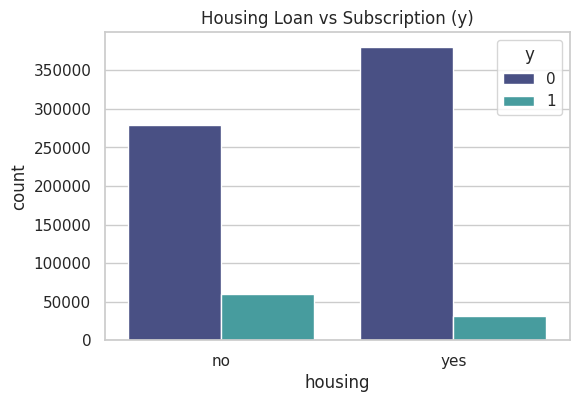

In [29]:
plt.figure(figsize=(6,4))
sns.countplot(x='housing', hue='y', data=train, palette="mako")
plt.title("Housing Loan vs Subscription (y)")
plt.show()

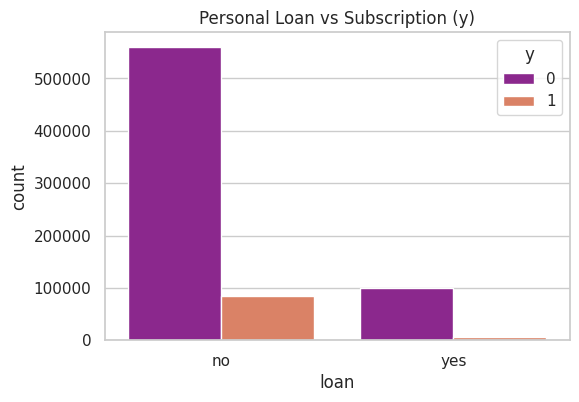

In [30]:
plt.figure(figsize=(6,4))
sns.countplot(x='loan', hue='y', data=train, palette="plasma")
plt.title("Personal Loan vs Subscription (y)")
plt.show()

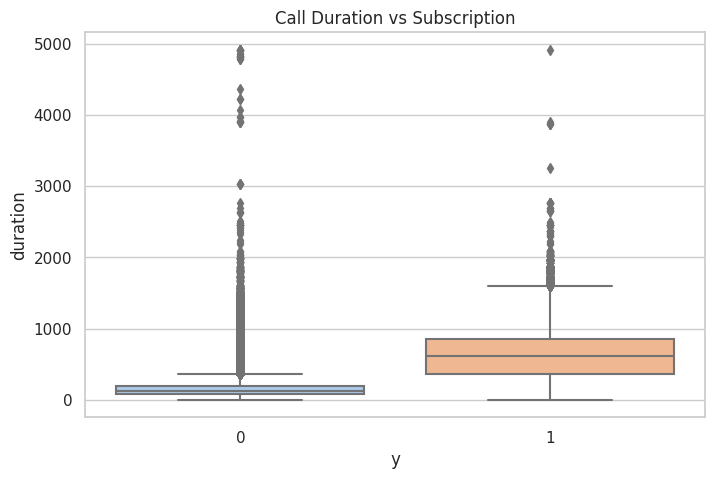

In [31]:
plt.figure(figsize=(8,5))
sns.boxplot(x='y', y='duration', data=train, palette="pastel")
plt.title("Call Duration vs Subscription")
plt.show()

Text(0.5, 1.0, 'Distribution of Campaign Contacts')

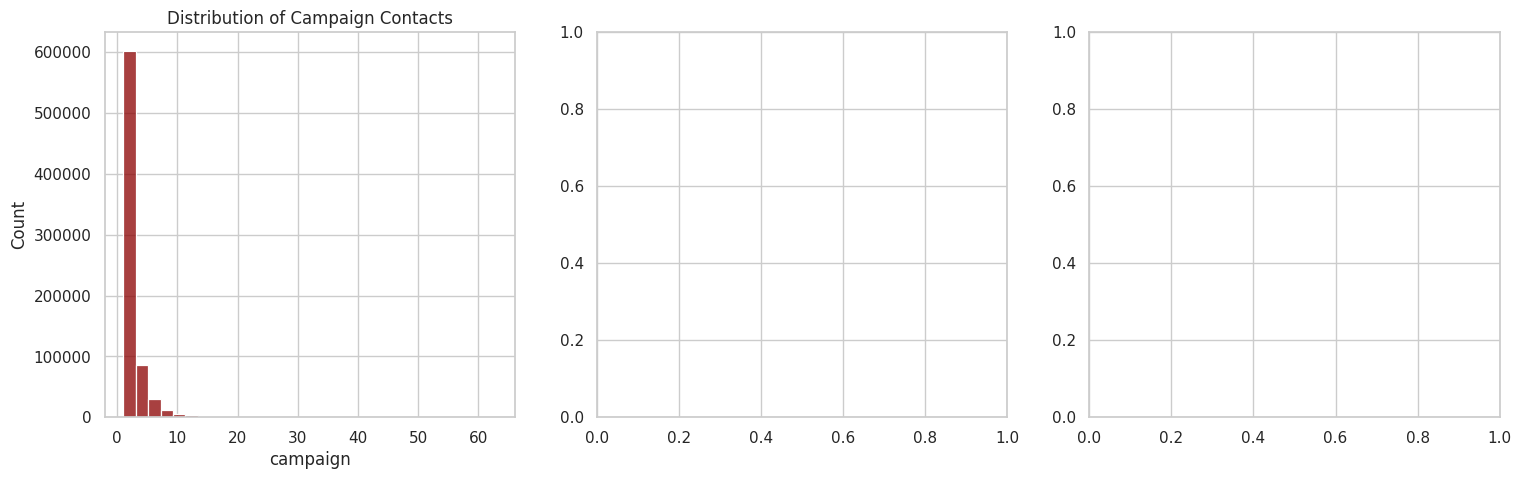

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))
sns.histplot(train['campaign'], bins=30, ax=axes[0], color="darkred")
axes[0].set_title("Distribution of Campaign Contacts")

In [33]:
sns.histplot(train['pdays'], bins=30, ax=axes[1], color="darkblue")
axes[1].set_title("Distribution of Days Passed After Last Contact (pdays)")

sns.histplot(train['previous'], bins=30, ax=axes[2], color="darkgreen")
axes[2].set_title("Distribution of Previous Contacts")
plt.show()

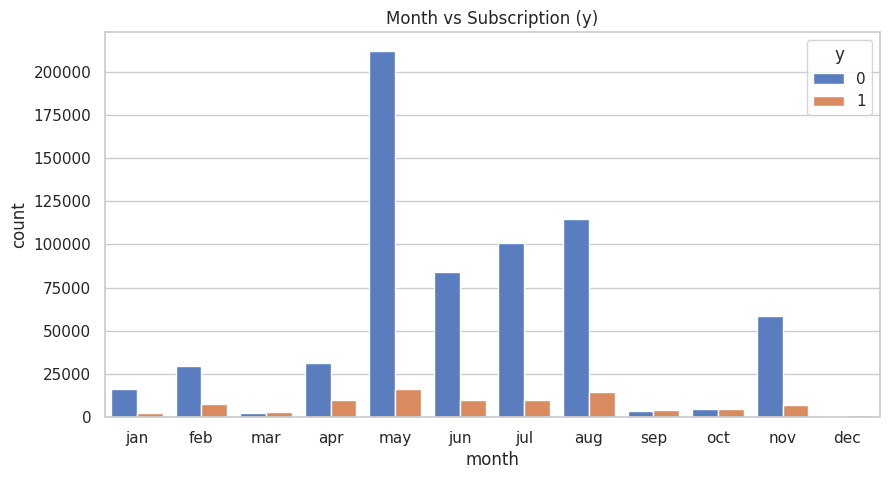

In [34]:
plt.figure(figsize=(10,5))
sns.countplot(x='month', hue='y', data=train, order=['jan','feb','mar','apr','may','jun','jul','aug','sep','oct','nov','dec'])
plt.title("Month vs Subscription (y)")
plt.show()

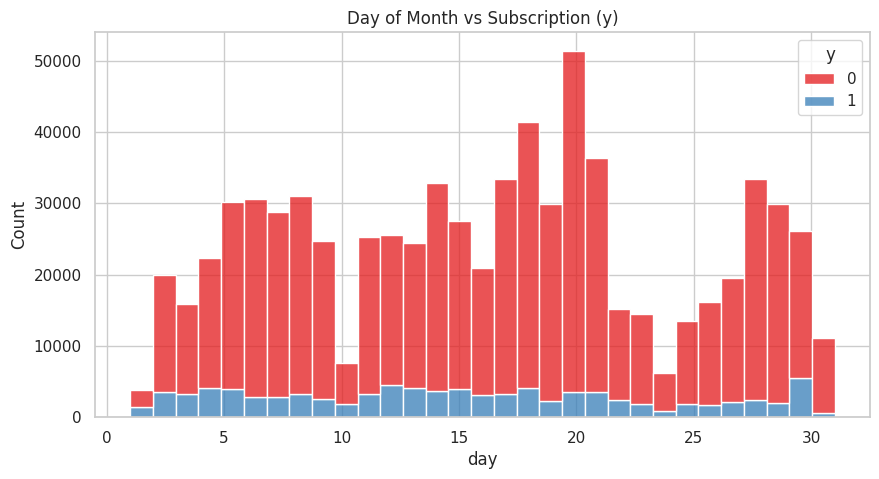

In [35]:
plt.figure(figsize=(10,5))
sns.histplot(data=train, x="day", hue="y", multiple="stack", bins=31, palette="Set1")
plt.title("Day of Month vs Subscription (y)")
plt.show()

## Test data

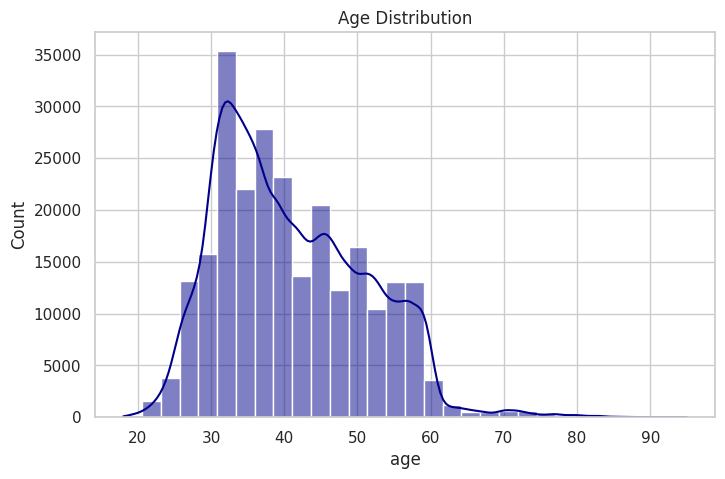

In [36]:
plt.figure(figsize=(8,5))
sns.histplot(test['age'], bins=30, kde=True, color="darkblue")
plt.title("Age Distribution")
plt.show()

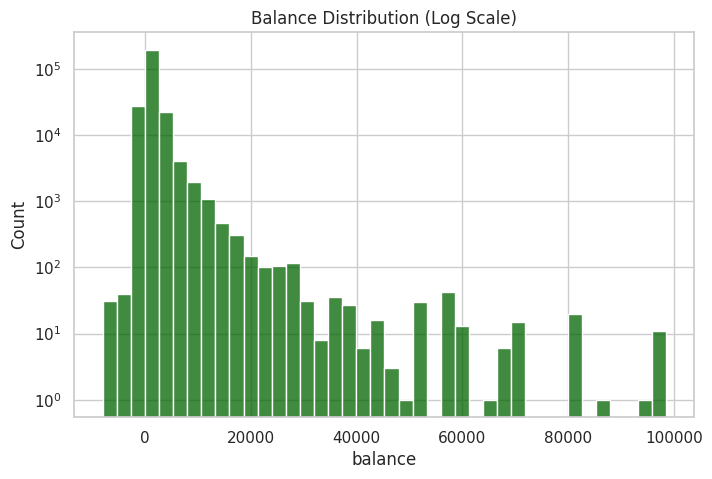

In [37]:
plt.figure(figsize=(8,5))
sns.histplot(test['balance'], bins=40, color="darkgreen")
plt.yscale("log")
plt.title("Balance Distribution (Log Scale)")
plt.show()

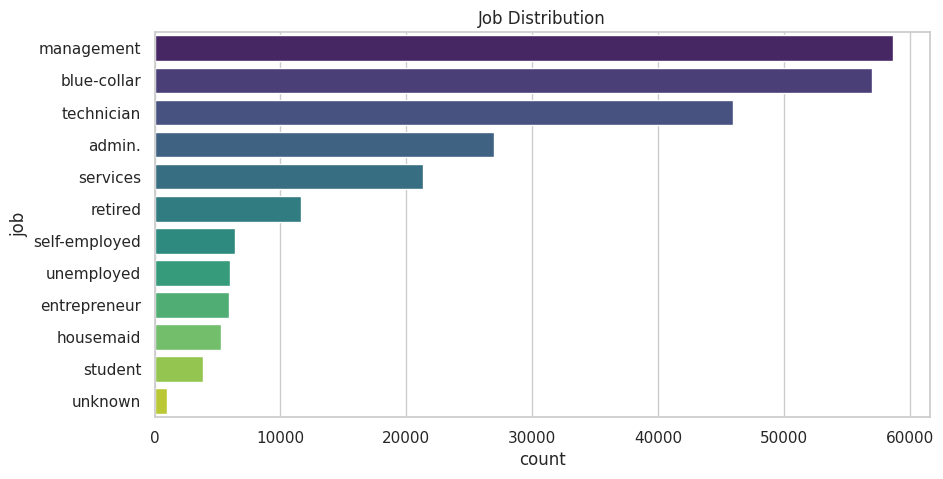

In [38]:
plt.figure(figsize=(10,5))
sns.countplot(y=test['job'], order=test['job'].value_counts().index, palette="viridis")
plt.title("Job Distribution")
plt.show()

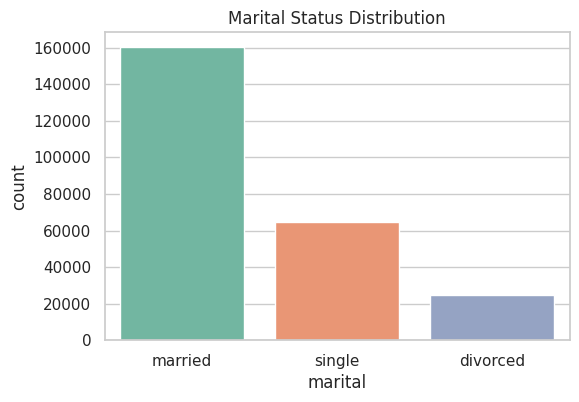

In [39]:
plt.figure(figsize=(6,4))
sns.countplot(x=test['marital'], palette="Set2")
plt.title("Marital Status Distribution")
plt.show()

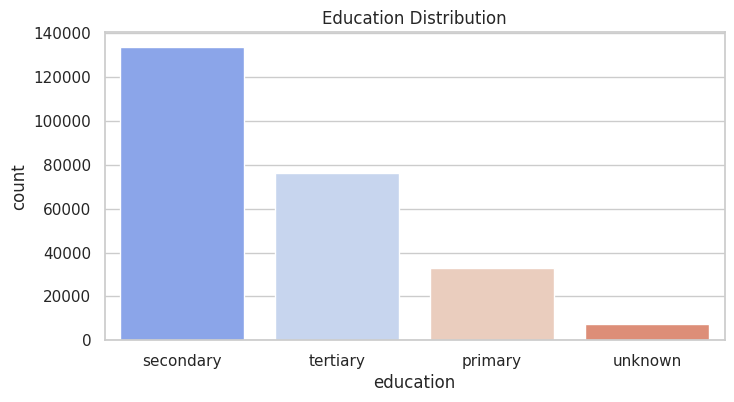

In [40]:
plt.figure(figsize=(8,4))
sns.countplot(x=test['education'], palette="coolwarm")
plt.title("Education Distribution")
plt.show()

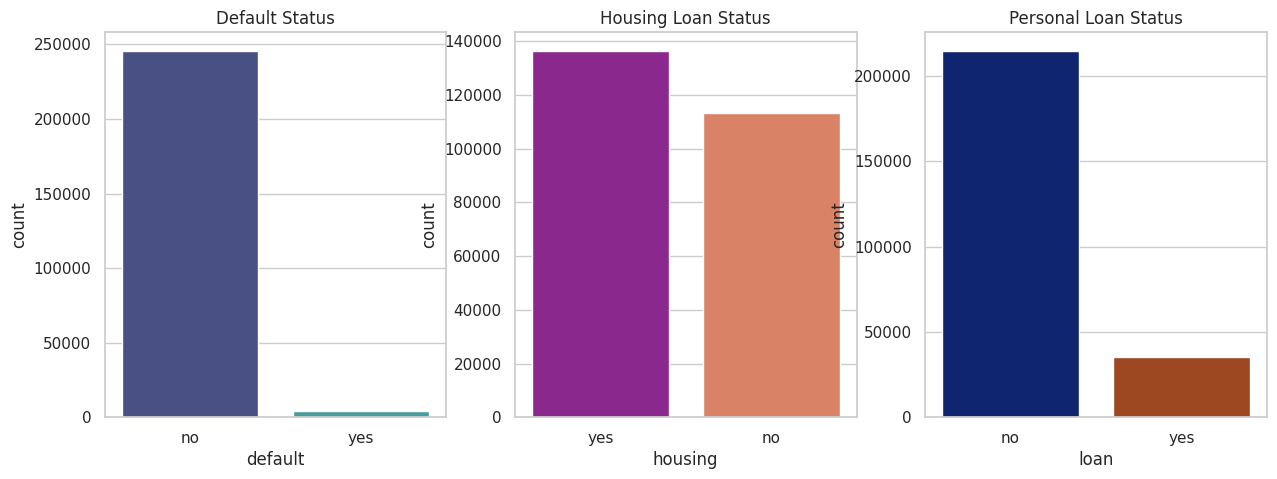

In [41]:
fig, axes = plt.subplots(1, 3, figsize=(15,5))
sns.countplot(x=test['default'], ax=axes[0], palette="mako")
axes[0].set_title("Default Status")

sns.countplot(x=test['housing'], ax=axes[1], palette="plasma")
axes[1].set_title("Housing Loan Status")

sns.countplot(x=test['loan'], ax=axes[2], palette="dark")
axes[2].set_title("Personal Loan Status")
plt.show()


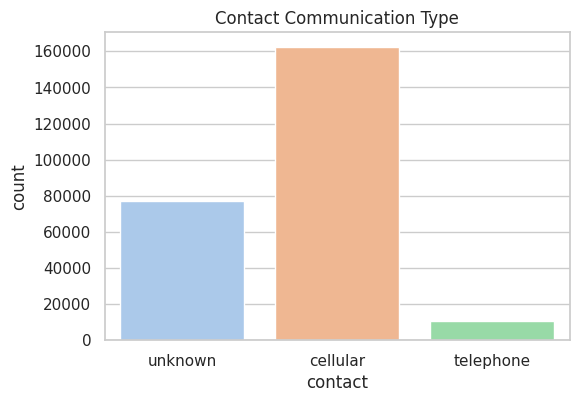

In [42]:
plt.figure(figsize=(6,4))
sns.countplot(x=test['contact'], palette="pastel")
plt.title("Contact Communication Type")
plt.show()

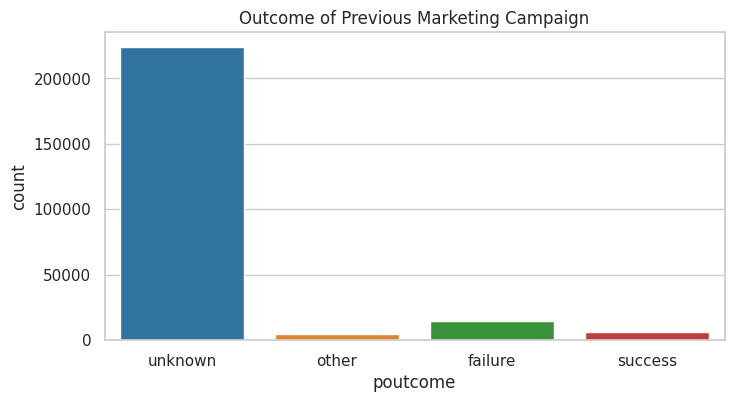

In [43]:
plt.figure(figsize=(8,4))
sns.countplot(x=test['poutcome'], palette="tab10")
plt.title("Outcome of Previous Marketing Campaign")
plt.show()

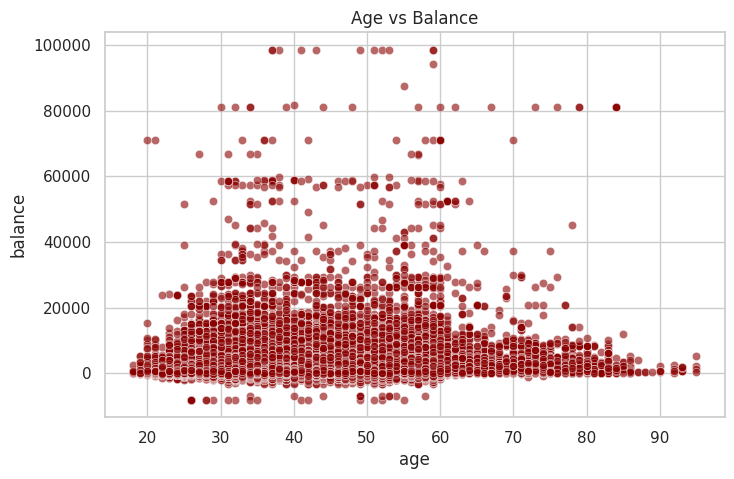

In [44]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="age", y="balance", data=test, alpha=0.6, color="darkred")
plt.title("Age vs Balance")
plt.show()

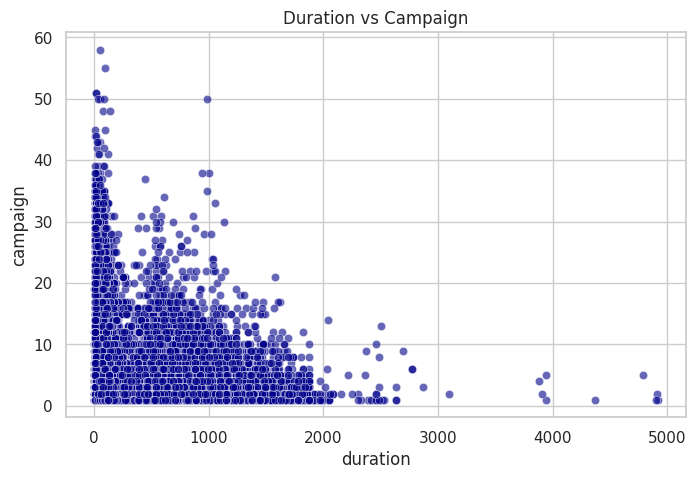

In [45]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="duration", y="campaign", data=test, alpha=0.6, color="darkblue")
plt.title("Duration vs Campaign")
plt.show()

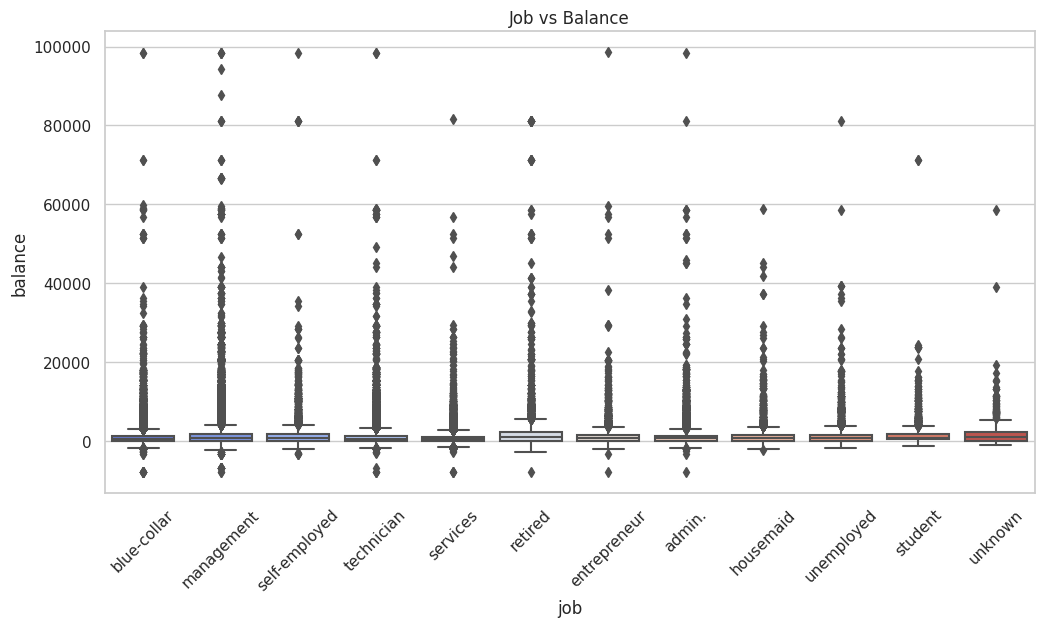

In [46]:
plt.figure(figsize=(12,6))
sns.boxplot(x="job", y="balance", data=test, palette="coolwarm")
plt.xticks(rotation=45)
plt.title("Job vs Balance")
plt.show()

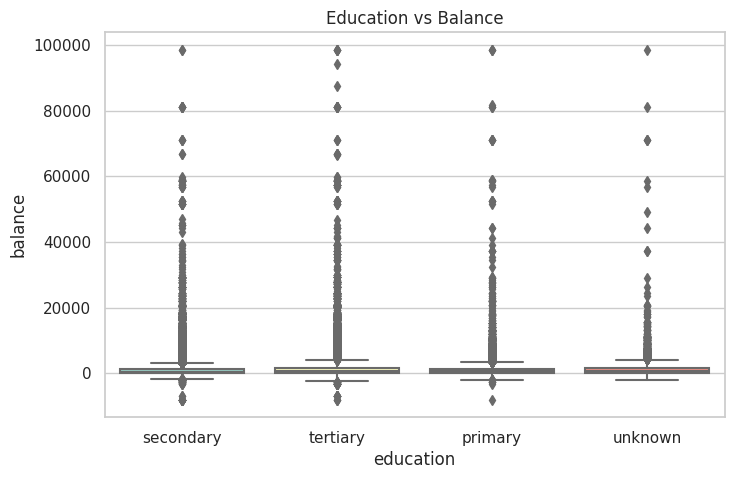

In [47]:
plt.figure(figsize=(8,5))
sns.boxplot(x="education", y="balance", data=test, palette="Set3")
plt.title("Education vs Balance")
plt.show()

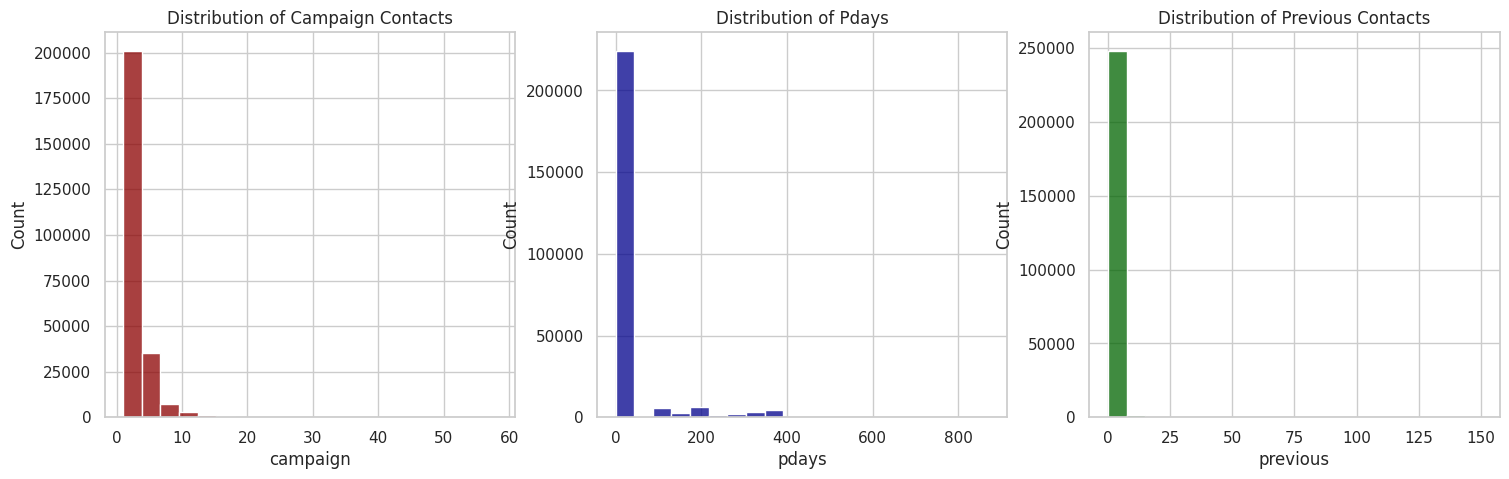

In [48]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))
sns.histplot(test['campaign'], bins=20, ax=axes[0], color="darkred")
axes[0].set_title("Distribution of Campaign Contacts")

sns.histplot(test['pdays'], bins=20, ax=axes[1], color="darkblue")
axes[1].set_title("Distribution of Pdays")

sns.histplot(test['previous'], bins=20, ax=axes[2], color="darkgreen")
axes[2].set_title("Distribution of Previous Contacts")
plt.show()

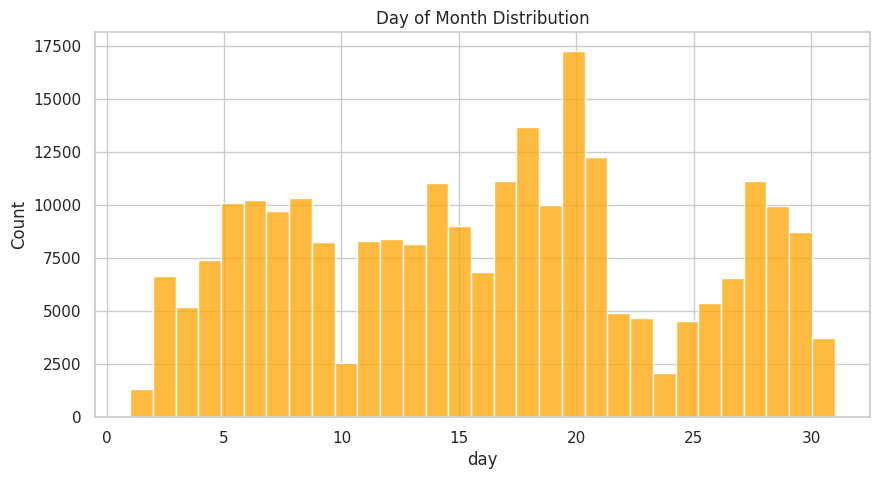

In [49]:
plt.figure(figsize=(10,5))
sns.histplot(test['day'], bins=31, color="orange")
plt.title("Day of Month Distribution")
plt.show()


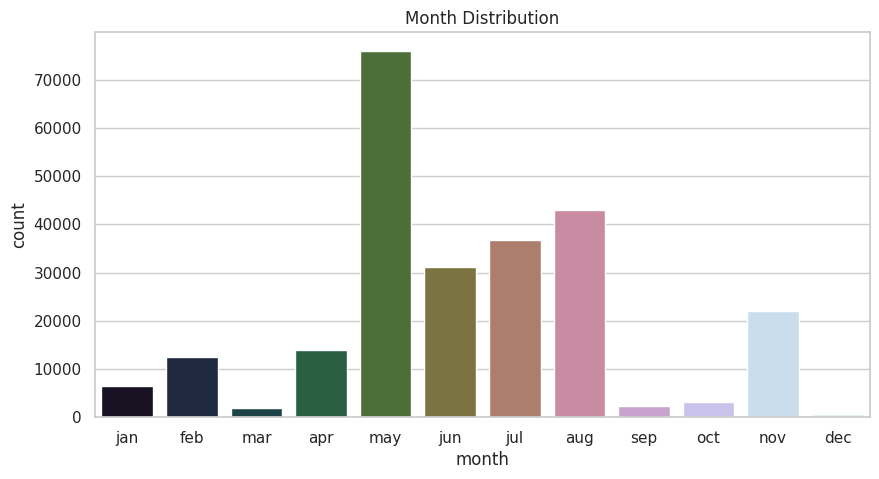

In [50]:
plt.figure(figsize=(10,5))
sns.countplot(x='month', data=test, order=['jan','feb','mar','apr','may','jun','jul','aug','sep','oct','nov','dec'], palette="cubehelix")
plt.title("Month Distribution")
plt.show()

## Predictive modeling

In [51]:
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from catboost import CatBoostClassifier
from sklearn.metrics import roc_auc_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

In [52]:
sample =pd.read_csv('/kaggle/input/playground-series-s5e8/sample_submission.csv')

In [53]:
X = train.drop('y', axis=1).astype('str')
y = train['y']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, shuffle=True, stratify=y, random_state=0)

In [54]:
train = pd.concat([train, sample], ignore_index=True)
train = train.drop_duplicates()

In [55]:
cat_clf = CatBoostClassifier(
    cat_features=X.columns.to_list(),   # categorical features
    task_type='CPU',                   # use CPU (change to 'GPU' if available)
    devices='1',                       # specific device if needed
    n_estimators=3000,                 # total boosting iterations
    learning_rate=0.068,               # step size shrinkage
    depth=12,                          # depth of trees
    l2_leaf_reg=2,                     # L2 regularization
    subsample=0.8,                     # subsampling ratio for bagging
    allow_writing_files=True,          # allow writing files
    save_snapshot=True,                # snapshot to resume training if interrupted
    snapshot_file='catboost_checkpoint.cb',
    snapshot_interval=600,
    verbose=100                        # log training every 100 iterations
)

# Train the model with early stopping
cat_clf.fit(
    X_train, y_train,
    eval_set=(X_test, y_test),
    early_stopping_rounds=300
)

# Save the trained model
cat_clf.save_model("catboost_final_model.cbm")

# Reload model (for demonstration / future use)
loaded_model = CatBoostClassifier()
loaded_model.load_model("catboost_final_model.cbm")

# Predict probabilities
y_pred_proba = loaded_model.predict_proba(X_test)[:, 1]

# Evaluate with ROC-AUC
roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"ROC-AUC Score: {roc_auc:.4f}")

0:	learn: 0.5650146	test: 0.5646338	best: 0.5646338 (0)	total: 5.14s	remaining: 4h 16m 51s
100:	learn: 0.1304163	test: 0.1362509	best: 0.1362509 (100)	total: 8m 23s	remaining: 4h 45s
200:	learn: 0.1177331	test: 0.1342928	best: 0.1342806 (199)	total: 17m 21s	remaining: 4h 1m 38s
300:	learn: 0.1071898	test: 0.1338374	best: 0.1338374 (300)	total: 25m 58s	remaining: 3h 52m 52s
400:	learn: 0.0987614	test: 0.1336796	best: 0.1336599 (389)	total: 34m 22s	remaining: 3h 42m 47s
500:	learn: 0.0919430	test: 0.1336612	best: 0.1335456 (463)	total: 42m 52s	remaining: 3h 33m 49s
600:	learn: 0.0852818	test: 0.1336468	best: 0.1335456 (463)	total: 51m 19s	remaining: 3h 24m 54s
700:	learn: 0.0798000	test: 0.1337693	best: 0.1335456 (463)	total: 59m 37s	remaining: 3h 15m 32s
Stopped by overfitting detector  (300 iterations wait)

bestTest = 0.1335455714
bestIteration = 463

Shrink model to first 464 iterations.
ROC-AUC Score: 0.9729


In [56]:
test_pred = cat_clf.predict_proba(test.astype('str'))[:, 1]

In [57]:
sub = pd.read_csv("/kaggle/input/playground-series-s5e8/sample_submission.csv")
sub['y'] = test_pred
sub.to_csv("submission_2000e1.csv", index=False)
sub.head()

,id,y
0,750000,0.005727
1,750001,0.059005
2,750002,0.000343
3,750003,0.000142
4,750004,0.022329
